In [5]:
# importing raw data
df = pd.read_csv('king_county_housing_data.csv')

In [6]:
# Preview data
df.head()

,Unnamed: 0,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,house_id,id.1
0,0,7129300520,3.0,1.00,1180.0,5650.0,1.0,NaN,0.0,3,...,0.0,98178,47.5112,-122.257,1340.0,5650.0,2014-10-13,221900.0,7129300520,1
1,1,6414100192,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3,...,19910.0,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0,6414100192,2
2,2,5631500400,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3,...,NaN,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0,5631500400,3
3,3,2487200875,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5,...,0.0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0,2487200875,4
4,4,1954400510,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3,...,0.0,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0,1954400510,5


In [7]:
# Basic info, Spalten & Data type, Nullzellen
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     21597 non-null  int64  
 1   id             21597 non-null  int64  
 2   bedrooms       21597 non-null  float64
 3   bathrooms      21597 non-null  float64
 4   sqft_living    21597 non-null  float64
 5   sqft_lot       21597 non-null  float64
 6   floors         21597 non-null  float64
 7   waterfront     19206 non-null  float64
 8   view           21534 non-null  float64
 9   condition      21597 non-null  int64  
 10  grade          21597 non-null  int64  
 11  sqft_above     21597 non-null  float64
 12  sqft_basement  21145 non-null  float64
 13  yr_built       21597 non-null  int64  
 14  yr_renovated   17749 non-null  float64
 15  zipcode        21597 non-null  int64  
 16  lat            21597 non-null  float64
 17  long           21597 non-null  float64
 18  sqft_l

| Data Type              | Examples in Dataset                                      | Descriptive Statistic | Visualization
|------------------------|----------------------------------------------------------|-----------------------|-----------------|
| Numerical              | price, sqft_living, sqft_lot, bedrooms, bathrooms, floors, sqft_above, sqft_basement | mean, median, min, max, std, quartiles (Q1–Q3), IQR,  |  histogram, boxplot, scatter plot, correlation |
| Categorical / Ordinal  | condition, grade, view, waterfront                       | frequency counts, mode |  bar chart |
| Temporal               | date (date of sale), yr_build, yr_renovated   | time series analysis, monthly/weekly aggregation,  |  line plot, bar plot (counts over time) |
| Geospatial             | lat (latitude), long (longitude), zipcode                | groupby (zipcode averages) | scatter plot (geo map), heatmap, spatial clustering |

In [8]:
# Shape of dataset
df.shape

(21597, 24)

- #features: korrigieren!!!! 23 columns
- #properties: 21597

ToDo: Delete: Usernamed, id.1, house_id=id
ToDo: Umwandeln yr_renovated float64->int64, waterfront, view, 
ToDo: Umwandeln date object in date

In [9]:
#Check duplicates
df.duplicated().sum()

np.int64(0)

In [10]:
# Check missing values
df.isnull().sum()

Unnamed: 0          0
id                  0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront       2391
view               63
condition           0
grade               0
sqft_above          0
sqft_basement     452
yr_built            0
yr_renovated     3848
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
date                0
price               0
house_id            0
id.1                0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Unnamed: 0     21597 non-null  int64         
 1   id             21597 non-null  int64         
 2   bedrooms       21597 non-null  float64       
 3   bathrooms      21597 non-null  float64       
 4   sqft_living    21597 non-null  float64       
 5   sqft_lot       21597 non-null  float64       
 6   floors         21597 non-null  float64       
 7   waterfront     19206 non-null  float64       
 8   view           21534 non-null  float64       
 9   condition      21597 non-null  int64         
 10  grade          21597 non-null  int64         
 11  sqft_above     21597 non-null  float64       
 12  sqft_basement  21145 non-null  float64       
 13  yr_built       21597 non-null  int64         
 14  yr_renovated   17749 non-null  float64       
 15  zipcode        2159

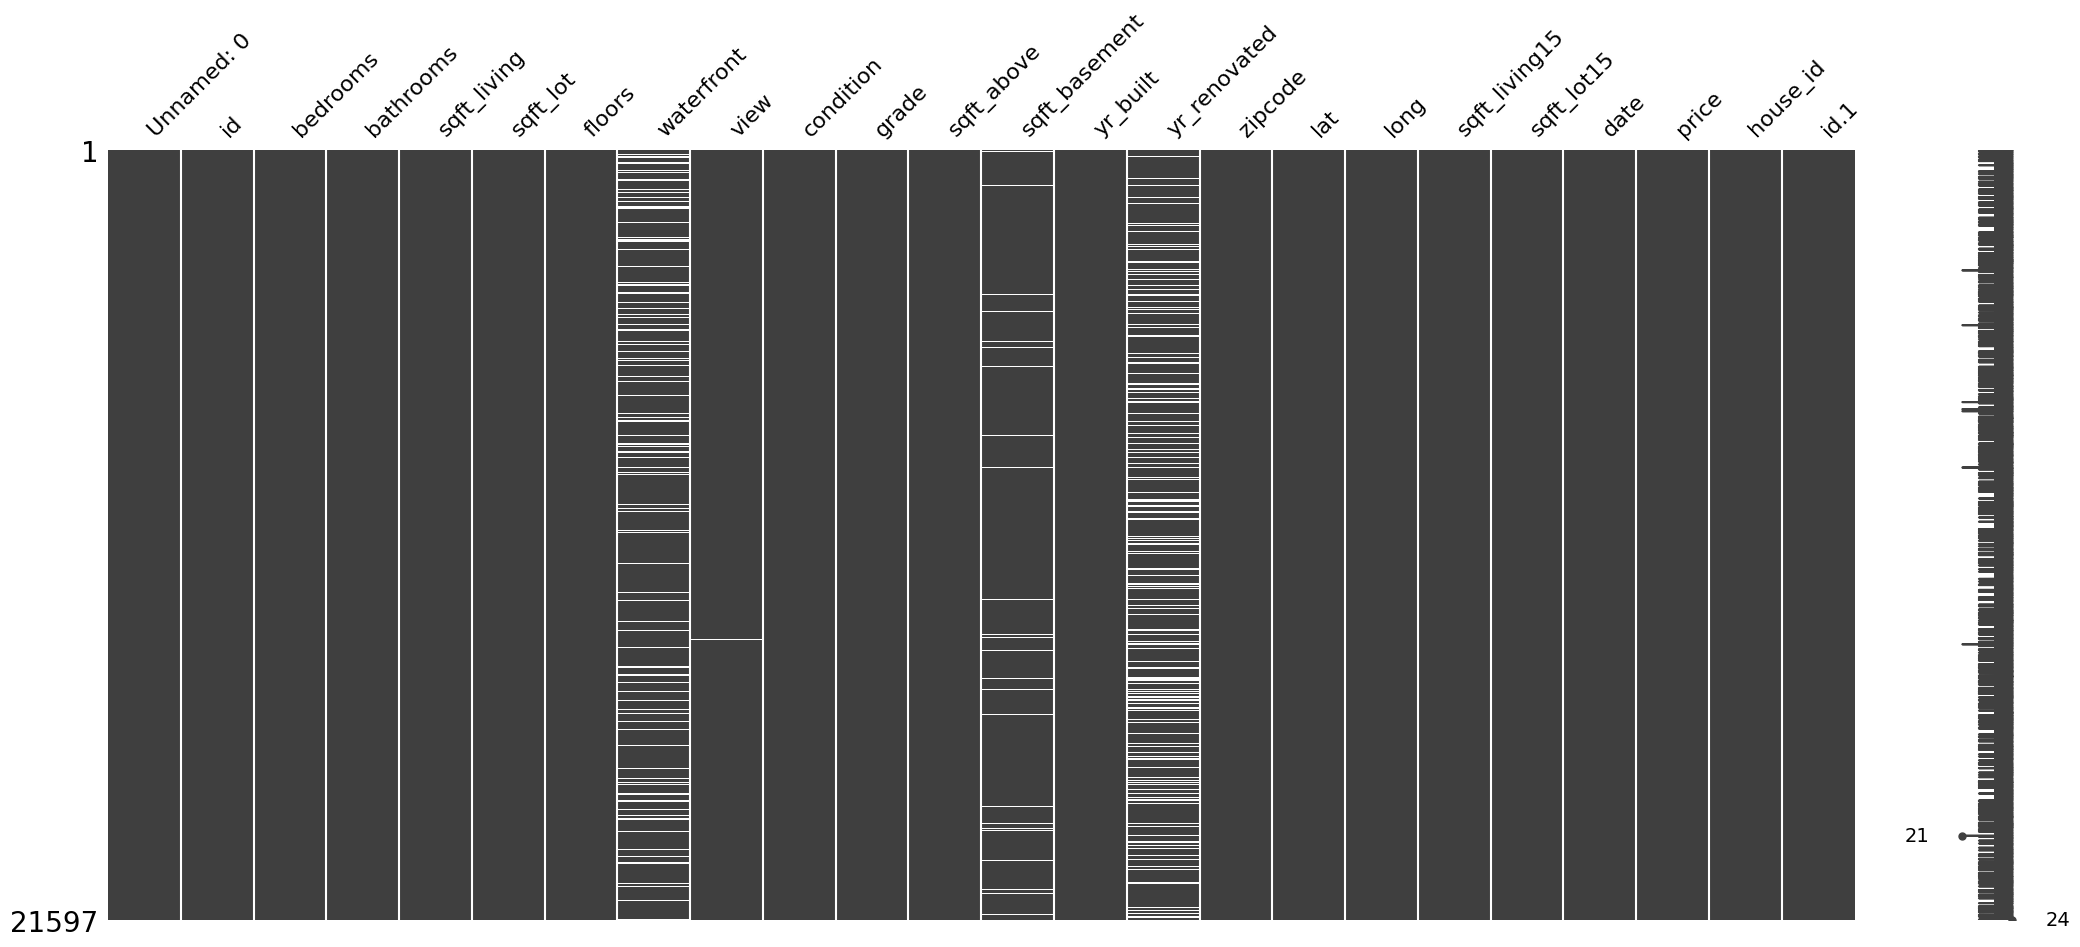

In [11]:
#Change Datatyp Date

import missingno as msgn

#--> no missing data
#--> data types make sense for each column
from datetime import date
from datetime import datetime

df["date"] = pd.to_datetime(df["date"],format="%Y-%m-%d")

df['date'].dt.date
df.isna()
print(df.info())
print(msgn.matrix(df))

- fehlende Werte bei Waterfront (weder 0;1)
- 1x view
- sqft_basement = keine Keller?
- yr_renovation = keine Renovierung?

In [12]:
# Summary statistics for numerical columns
df.describe()

,Unnamed: 0,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,house_id,id.1
count,21597.000000,2.159700e+04,21597.000000,21597.000000,21597.000000,2.159700e+04,21597.000000,19206.000000,21534.000000,21597.000000,...,17749.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597,2.159700e+04,2.159700e+04,21597.000000
mean,10798.000000,4.580474e+09,3.373200,2.115826,2080.321850,1.509941e+04,1.494096,0.007602,0.233863,3.409825,...,836.650516,98077.951845,47.560093,-122.213983,1986.620318,12758.283512,2014-10-29 04:20:38.171968512,5.402966e+05,4.580474e+09,10799.000000
min,0.000000,1.000102e+06,1.000000,0.500000,370.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,...,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000,2014-05-02 00:00:00,7.800000e+04,1.000102e+06,1.000000
25%,5399.000000,2.123049e+09,3.000000,1.750000,1430.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,...,0.000000,98033.000000,47.471100,-122.328000,1490.000000,5100.000000,2014-07-22 00:00:00,3.220000e+05,2.123049e+09,5400.000000
50%,10798.000000,3.904930e+09,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,...,0.000000,98065.000000,47.571800,-122.231000,1840.000000,7620.000000,2014-10-16 00:00:00,4.500000e+05,3.904930e+09,10799.000000
75%,16197.000000,7.308900e+09,4.000000,2.500000,2550.000000,1.068500e+04,2.000000,0.000000,0.000000,4.000000,...,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000,2015-02-17 00:00:00,6.450000e+05,7.308900e+09,16198.000000
max,21596.000000,9.900000e+09,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,...,20150.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000,2015-05-27 00:00:00,7.700000e+06,9.900000e+09,21597.000000
std,6234.661218,2.876736e+09,0.926299,0.768984,918.106125,4.141264e+04,0.539683,0.086858,0.765686,0.650546,...,4000.110554,53.513072,0.138552,0.140724,685.230472,27274.441950,NaN,3.673681e+05,2.876736e+09,6234.661218


In [13]:
def plot_histogram(column, bins=30):
    plt.figure()
    plt.hist(df[column], bins=bins)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

In [14]:
df['date'].dt.date

0        2014-10-13
1        2014-12-09
2        2015-02-25
3        2014-12-09
4        2015-02-18
            ...    
21592    2014-05-21
21593    2015-02-23
21594    2014-06-23
21595    2015-01-16
21596    2014-10-15
Name: date, Length: 21597, dtype: object

In [15]:
df['date'].describe()

count                            21597
mean     2014-10-29 04:20:38.171968512
min                2014-05-02 00:00:00
25%                2014-07-22 00:00:00
50%                2014-10-16 00:00:00
75%                2015-02-17 00:00:00
max                2015-05-27 00:00:00
Name: date, dtype: object

In [16]:
df['date'] = pd.to_datetime(df['date'])

df['date'].min(), df['date'].max()

(Timestamp('2014-05-02 00:00:00'), Timestamp('2015-05-27 00:00:00'))

Warum wieder data type = object?

Immobilienverkäufe zwischen Mai 2014 [2014-05-02] und Mai 2015 [2015-05-27]

In [20]:
#zeitliche Verteilung der Verkäufe
df["month"] = df["date"].dt.month

plt.figure()
df["month"].value_counts().sort_index().plot(kind="bar")
plt.title("Number of Sales per Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

NameError: name 'plt' is not defined

In [21]:
# Count Top sales per month
df["month"] = df["date"].dt.month
sales_per_month = df["month"].value_counts().sort_index()
top_month = sales_per_month.idxmax()
top_sales = sales_per_month.max()

top_month, top_sales

(np.int32(5), np.int64(2414))

In [24]:
df['price'].describe().round(2)

count      21597.00
mean      540296.57
std       367368.14
min        78000.00
25%       322000.00
50%       450000.00
75%       645000.00
max      7700000.00
Name: price, dtype: float64

In [23]:
#Verteilung der Preise
plot_histogram("price", bins=50)

NameError: name 'plt' is not defined

In [25]:
plt.figure()
plt.boxplot(df["price"])
plt.title("Boxplot of Price")
plt.show()

NameError: name 'plt' is not defined

NameError: name 'plt' is not defined

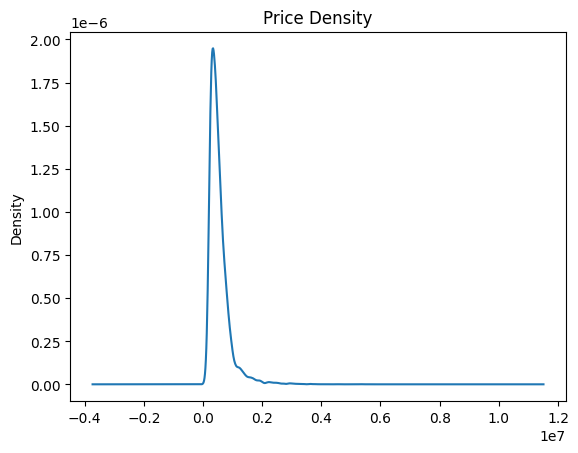

In [26]:
df["price"].plot(kind="kde", title="Price Density")
plt.show()

In [27]:
df[['sqft_living', 'sqft_lot']].describe().round(0)

,sqft_living,sqft_lot
count,21597.0,21597.0
mean,2080.0,15099.0
std,918.0,41413.0
min,370.0,520.0
25%,1430.0,5040.0
50%,1910.0,7618.0
75%,2550.0,10685.0
max,13540.0,1651359.0


In [28]:
#Benchmarking Neighborhood
df[['sqft_living15', 'sqft_lot15']].describe().round(0)

,sqft_living15,sqft_lot15
count,21597.0,21597.0
mean,1987.0,12758.0
std,685.0,27274.0
min,399.0,651.0
25%,1490.0,5100.0
50%,1840.0,7620.0
75%,2360.0,10083.0
max,6210.0,871200.0


In [29]:
#Verteilung
plot_histogram("sqft_living")
plot_histogram("sqft_living15")
plot_histogram("sqft_lot")
plot_histogram("sqft_lot15")

NameError: name 'plt' is not defined

In [ ]:
#living space relative to lot size
df["living_to_lot_ratio"] = df["sqft_living"] / df["sqft_lot"]

(df["sqft_lot"] == 0).sum()

df["living_to_lot_ratio"].describe()

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["living_to_lot_ratio"], bins=50)
plt.title("Distribution of Living-to-Lot Ratio")
plt.xlabel("Living / Lot Ratio")
plt.ylabel("Frequency")
plt.show()


In [ ]:
df[['bedrooms', 'bathrooms']].describe().round(1)

In [ ]:
#Verteilung
df["bedrooms"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Count of Houses")
plt.show()


bath_counts = df["bathrooms"].round().value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Count of Houses")
plt.show()


In [ ]:
#Floors
df['floors'].describe().round(1)

In [ ]:
#Verteilung
df["floors"].value_counts().sort_index().plot(kind="bar")
plt.title("Floors Distribution")
plt.show()

In [ ]:
waterfront_counts = df["waterfront"].value_counts().sort_index()
waterfront_percent = (df["waterfront"].value_counts(normalize=True).sort_index() * 100).round(2)

result = pd.DataFrame({
    "count": waterfront_counts,
    "percentage (%)": waterfront_percent
})

result

In [ ]:
cat_cols = ["view", "waterfront"]

summary_cat = pd.DataFrame({
    "unique_values": df[cat_cols].nunique(),
    "most_common": df[cat_cols].mode().iloc[0],
    "total": df[cat_cols].count().iloc[0],
})

summary_cat

In [ ]:
view_counts = df["view"].value_counts().sort_index()
view_percent = (df["view"].value_counts(normalize=True).sort_index()*100).round(2)

result = pd.DataFrame({
    "count": view_counts,
    "%": view_percent
})

result

In [ ]:
#Verteilung
df["waterfront"].value_counts().sort_index().plot(kind="bar")
plt.title("Waterfront Distribution")
plt.show()

df["view"].value_counts().sort_index().plot(kind="bar")
plt.title("View Distribution")
plt.show()

In [ ]:
df[['sqft_above', 'sqft_basement']].describe().round(0)

In [ ]:
#Verteilung
plot_histogram("sqft_above")
plot_histogram("sqft_basement")

In [ ]:
#Build & Renovierung
df[["yr_built", "yr_renovated"]].describe()


In [ ]:
#Korrektur skalierung

df["yr_renovated"] = df["yr_renovated"].apply(
    lambda x: x / 10 if x > 10000 else x)


In [ ]:
df["yr_renovated"] = df["yr_renovated"].replace(0, None)

In [ ]:
# yr_built bereinigen
df["yr_built"] = pd.to_numeric(df["yr_built"], errors="coerce").astype("Int64")

# yr_renovated bereinigen
df["yr_renovated"] = (
    pd.to_numeric(df["yr_renovated"], errors="coerce")
    .replace(0, pd.NA)
    .astype("Int64")
)

In [ ]:
#kontrolle
df[["yr_built", "yr_renovated"]].describe()

In [ ]:
df[["yr_built", "yr_renovated"]].mode()

In [ ]:
plt.figure()
plt.hist(df["yr_built"], bins=30)
plt.title("Distribution of Year Built")
plt.xlabel("Year Built")
plt.ylabel("Frequency")
plt.show()


plt.figure()
plt.hist(df["yr_renovated"], bins=30)
plt.title("Distribution of Year of Renovation")
plt.xlabel("Year Renovation")
plt.ylabel("Frequency")
plt.show()


df["renovated"] = df["yr_renovated"].apply(lambda x: 0 if x == 0 else 1)
df["renovated"].value_counts().plot(kind="bar")
plt.title("Renovated vs Non-Renovated Houses")
plt.xticks([0,1], ["Not Renovated", "Renovated"], rotation=0)
plt.show()

In [ ]:
#New_Variable: Age of House
df["year_sold"] = df["date"].dt.year
df["house_age"] = df["year_sold"] - df["yr_built"]

df["house_age"].describe()

In [ ]:
df["house_age"].mode()

In [ ]:
df["renovated"].value_counts()

In [ ]:
plt.figure()
plt.hist(df["house_age"], bins=30)
plt.title("Distribution of House Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [ ]:
cat_cols = ["grade", "condition"]

summary_cat = pd.DataFrame({
    "unique_values": df[cat_cols].nunique(),
    "most_common": df[cat_cols].mode().iloc[0],
})

summary_cat

In [ ]:
#Bewertung/Verteilung
df["condition"].value_counts().sort_index()

In [ ]:
df["grade"].value_counts().sort_index()

In [ ]:
#Verteilung
df["condition"].value_counts().sort_index().plot(kind="bar")
plt.title("Conditions Distribution")
plt.show()

df["grade"].value_counts().sort_index().plot(kind="bar")
plt.title("Grade Distribution")
plt.show()

In [ ]:
plt.figure()

df["zipcode"].value_counts().sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top 10 ZIP Codes by Number of Sales")
plt.xlabel("ZIP Code")
plt.ylabel("Number of Sales")
plt.xticks(rotation=45)
plt.show()

#Average Price per ZIP Code
avg_price_zip = df.groupby("zipcode")["price"].mean().sort_values(ascending=False)

plt.figure()
avg_price_zip.head(10).plot(kind="bar")

plt.title("Top 10 ZIP Codes by Average Price")
plt.xlabel("ZIP Code")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

#Cheapest vs Most Expensive Areas
avg_price_zip.tail(10).plot(kind="bar", title="Cheapest ZIP Codes")
plt.xlabel("ZIP Code")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()


In [ ]:
#Check Coordinates
import matplotlib.pyplot as plt

plt.figure(figsize=(140,60))
plt.scatter(df["long"], df["lat"])

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Locations")
plt.show()


In [ ]:
# Average price per ZIP
zip_prices = df.groupby("zipcode")["price"].mean()

# Top & bottom 10
top_zips = zip_prices.sort_values(ascending=False).head(10).index
bottom_zips = zip_prices.sort_values().head(10).index

#filter data
df_top = df[df["zipcode"].isin(top_zips)]
df_bottom = df[df["zipcode"].isin(bottom_zips)]

#Plot Geo map
import matplotlib.pyplot as plt

plt.figure()

## Expensive ZIPs
plt.scatter(df_top["long"], df_top["lat"], label="Expensive ZIPs", alpha=0.5)

## Cheap ZIPs
plt.scatter(df_bottom["long"], df_bottom["lat"], label="Cheap ZIPs", alpha=0.5)

plt.title("Geographical Distribution of Expensive vs Cheap ZIP Codes")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()

plt.show()


## Hypotheses

The following hypotheses are formulated:

1. There is a positive relationship between sqft_living and house price.
2. Houses in central and/or waterfront ZIP codes have significantly higher prices than those in outer regions.
3. Newer or recently renovated houses have higher prices than older, non-renovated houses.
4. Higher living-to-lot ratio is associated with higher prices in central areas.
5. Higher construction quality (grade) leads to significantly higher property prices.
6. Property sales volume varies by month, indicating seasonal buying behavior.


Non:
•	**bedrooms**: Number of bedrooms
•	**bathrooms**: Number of bathrooms
•	**sqft_lot**: Lot size (in square feet)
•	**floors**: Number of floors
•	**view**: Quality of the view (ordinal scale: )
•	**condition**: Overall condition of the house
•	**sqft_above**: Square footage above ground
•	**sqft_basement**: Square footage of basement
•	**sqft_living15**: Average living space of the 15 nearest neighboring houses
•	**sqft_lot15**: Average lot size of the 15 nearest neighboring houses

## Analysis

In [ ]:
#Mid-Budget
q1 = df["price"].quantile(0.25)
q3 = df["price"].quantile(0.75)

q1, q3

In [ ]:
mid_range = df[(df["price"] >= 322000) & (df["price"] <= 645000)]

In [ ]:
mid_range[["sqft_living", "price"]].corr()

In [ ]:
import numpy as np

x = mid_range["sqft_living"]
y = mid_range["price"]

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.figure()
plt.scatter(x, y, alpha=0.3)
plt.plot(x, p(x),color="red")

plt.title("Price vs Living Space with Trendline (Mid-Range)")
plt.xlabel("sqft_living")
plt.ylabel("price")

plt.show()



### Result
- strong positive correlation
- larger homes → higher prices

**hypothesis confirmed**


### Recommendation
Within the mid-range price segment, the relationship between living space and price remains positive but becomes more linear and less influenced by extreme outliers. This allows for a more realistic assessment of value for a buyer like Nicole Johnson.

In [3]:
#'zipcode' --> 70 zipcodes
# , 'lat', 'long', 'house_id'
# based on Nicoles prefewrences (central, lively neighborhood, medium price range and timing to buy we chose the columns we need to investigate:)
# for us relevant columns: 'sqft_living', 'sqft_lot', 'condition', 'grade', 'zipcode', 'lat', 'long','date', 'price', 'house_id'
df = df[['sqft_living', 'sqft_lot', 'condition', 'grade', 'zipcode', 'lat', 'long','date', 'price', 'house_id']]
print("the ten zip codes with the highest amount of houses are:")
print(spatial_df.groupby("zipcode").count()["price"].sort_values(ascending=False).head(10))

NameError: name 'df' is not defined

In [4]:
#inspect long & latitude data
df.head()

NameError: name 'df' is not defined

In [ ]:
# setting a score for density - asked chatGPT how to do it

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

radius_km = 1

densities = []

for i, row in rel_df.iterrows():
    lat, lon = row["lat"], row["long"]
    
    # 🔹 Step 1: fast bounding box filter (~1km ≈ 0.01 degrees)
    subset = rel_df[
        (rel_df["lat"].between(lat - 0.02, lat + 0.02)) &
        (rel_df["long"].between(lon - 0.02, lon + 0.02))
    ]
    
    # 🔹 Step 2: exact distances
    distances = haversine(
        lat,
        lon,
        subset["lat"].values,
        subset["long"].values
    )
    
    # 🔹 Step 3: count neighbors
    count = np.sum(distances <= radius_km) - 1  # exclude itself
    
    densities.append(count)

rel_df["housing_density_1km"] = densities

In [ ]:
rel_df["density_per_km2"] = rel_df["housing_density_1km"] / (np.pi * 1**2)
rel_df["density_per_km2"]
bins = ["low","medium", "high","very high"]
rel_df["density"] = pd.cut(rel_df["density_per_km2"], bins=4, labels=[1,2, 3,4])
rel_df.head()

import seaborn as sns

sns.pairplot(data=rel_df, corner=True)

In [ ]:
np.mean(rel_df["price"])
rel_df[rel_df["density"]==4]["zipcode"].plot(kind="hist", bins=20, xticks=rel_df[rel_df["density"]==4]["zipcode"].unique())
rel_df[rel_df["density"]==4]["zipcode"].value_counts()
rel_df[rel_df["density"]==4]["zipcode"].unique()

In [5]:
# started to try to create scatter plot of only the highest density zipcodes and wanted to see only those buildings with below Mean pricing, but running into errors...

df_sub = rel_df[rel_df["zipcode"] == rel_df[rel_df["density"]==4]["zipcode"].unique()]
rel_df.loc[([rel_df["density"]==4]) & (rel_df["price"]<540296.57)]

NameError: name 'rel_df' is not defined

In [ ]:
#full scatterplot of all houses in our list
import matplotlib.pyplot as plt


plt.figure(figsize=(14,6))
plt.scatter(df_stu["long"], df_stu["lat"])

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Locations")
plt.show()

In [ ]:
zip_price = (
    mid_range.groupby("zipcode")["price"]
    .mean()
    .sort_values(ascending=False)
)

zip_price.head(30).round(2)

In [ ]:
zip_price.head(30).plot(kind="bar")

plt.title("Top ZIP Codes by Price (Mid-Range Only)")
plt.ylabel("Average Price")
plt.xlabel("ZIP Code")

plt.show()

In [ ]:
zip_waterfront = (
    mid_range.groupby(["zipcode", "waterfront"])["price"]
    .mean()
    .unstack()
)

In [ ]:
zip_waterfront["price_difference"] = zip_waterfront[1] - zip_waterfront[0]

zip_waterfront.sort_values(by="price_difference", ascending=False).head(30).round(2)

In [ ]:
zip_waterfront["avg_price"] = zip_waterfront.mean(axis=1)

zip_sorted = zip_waterfront.sort_values(by="avg_price", ascending=True)

In [ ]:
import matplotlib.pyplot as plt

zip_sorted[[0, 1]].dropna().head(30).plot(kind="bar")

plt.title("Price by ZIP Code and Waterfront (Mid-Range)")
plt.ylabel("Average Price")
plt.xlabel("ZIP Code")
plt.legend(["Non-Waterfront", "Waterfront"])

plt.show()

### Result
- Significant regional price differences
- ZIP codes in central locations or near water are significantly more expensive

**hypothesis confirmed**

### Recommendation
- The waterfront is more expensive, therefore most of the properties in the range are not located their.
- But not in outlying areas either
- Focus on “value-for-money locations”

In [ ]:
mid_range["year_sold"] = mid_range["date"].dt.year
mid_range["house_age"] = mid_range["year_sold"] - mid_range["yr_built"]

In [ ]:
import matplotlib.pyplot as plt

for r in [0, 1]:
    subset = mid_range[mid_range["renovated"] == r]
    plt.scatter(subset["house_age"], subset["price"], alpha=0.3, label=f"Renovated={r}")

plt.legend()
plt.title("House Age vs Price (Mid-Range, Renovated vs Not)")
plt.xlabel("House Age")
plt.ylabel("Price")
plt.show()

### Result
- The newer the house, the more expensive it is
- many new buildings
- Modernization increases property value

**hypothesis confirmed**


### Recommendation
- Increased value and higher prices for new construction and renovated properties
- Old, renovated houses cheaper as younger (new) builings

In [ ]:
df["living_to_lot_ratio"] = df["sqft_living"] / df["sqft_lot"]

plt.figure()
plt.scatter(df["living_to_lot_ratio"], df["price"], alpha=0.3)
plt.title("Price vs Living-to-Lot Ratio")
plt.xlabel("Living/Lot Ratio")
plt.ylabel("Price")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

mid_range = df[(df["price"] >= 322000) & (df["price"] <= 645000)].copy()

mid_range["living_to_lot_ratio"] = mid_range["sqft_living"] / mid_range["sqft_lot"]

x = mid_range["living_to_lot_ratio"]
y = mid_range["price"]

# lineare Regression (Trendlinie)
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.figure()

# Scatter
plt.scatter(x, y, alpha=0.3)

# Trendlinie (rot für bessere Sichtbarkeit)
plt.plot(x, p(x), color="red", linewidth=2)

plt.title("Price vs Living-to-Lot Ratio (Mid-Range) with Trendline")
plt.xlabel("Living/Lot Ratio")
plt.ylabel("Price")

plt.show()

### Result
- higher population density, often in urban, more expensive areas
- but lower than ZIP Code / sqft_living

**hypothesis partially confirmed**


### Recommendation
- weak to moderate to density
- indication of central, vibrant neighborhoods

In [ ]:
grade_analysis = mid_range.groupby("grade")["price"].agg(
    ["count", "mean", "median"]
).round(0)

grade_analysis

In [ ]:
import matplotlib.pyplot as plt

mid_range.groupby("grade")["price"].median().sort_index().plot(kind="bar")

plt.title("Median Price by Grade (Mid-Range)")
plt.xlabel("Grade")
plt.ylabel("Median Price")

plt.show()

In [ ]:
mid_range.boxplot(column="price", by="grade")

plt.title("Price Distribution by Grade (Mid-Range)")
plt.suptitle("")
plt.xlabel("Grade")
plt.ylabel("Price")

plt.show()

### Result
- clear linear increase

**hypothesis strongly confirmed**


### Recommendation
- Grades 7–8, Grade 6 has expensive outliners
- Good quality without a premium surcharge

In [ ]:
#dataprep for later manipulation & transformation
# various price/quality relations and timing relations regarding ideal time of sale

rel_df["month"] = rel_df['date'].dt.month
rel_df["quarter"] = rel_df['date'].dt.quarter

import numpy as np

rel_df["season"]=np.nan

# Spring = March till june / Summer = June till September /  Fall = september till December/ Winter = December till March
for i, month in enumerate(rel_df["month"]):
    if month in [3, 4, 5]:
        rel_df["season"][i]= "Spring"
    elif month in [6, 7, 8]:
        rel_df["season"][i]= "Summer"
    elif month in [9, 10, 11]:
        rel_df["season"][i]= "Fall"
    else:
        rel_df["season"][i]= "Winter"
rel_df.head(10)

In [ ]:

#dataprep for later manipulation & transformation
# various price/quality relations and timing relations regarding ideal time of sale

rel_df["month"] = rel_df['date'].dt.month
rel_df["quarter"] = rel_df['date'].dt.quarter

import numpy as np

rel_df["season"]=np.nan

# Spring = March till june / Summer = June till September /  Fall = september till December/ Winter = December till March
for i, month in enumerate(rel_df["month"]):
    if month in [3, 4, 5]:
        rel_df["season"][i]= 1
    elif month in [6, 7, 8]:
        rel_df["season"][i]= 2
    elif month in [9, 10, 11]:
        rel_df["season"][i]= 3
    else:
        rel_df["season"][i]= 4
rel_df.head(10)

In [ ]:
fig, ax1 = plt.subplots()

# Sales Volume
mid_range["month"].value_counts().sort_index().plot(
    kind="bar",
    ax=ax1,
    color="skyblue",
    alpha=0.6
)

ax1.set_ylabel("Number of Sales")
ax1.set_xlabel("Month")
ax1.set_title("Sales Volume and Price Overview (Mid-Range)")

# Price Overview
ax2 = ax1.twinx()

monthly_price = mid_range.groupby("month")["price"].mean().sort_index()
ax2.plot(monthly_price.index, monthly_price.values, color="red", marker="o")

ax2.set_ylabel("Average Price")

plt.show()

### Result
- Seasonal fluctuations present

**hypothesis confirmed**


### Recommendation
- Buy, when less competition during slower months (winter, spring)
- Better negotiating leverage
- The price will decline after New Year's (since the beginning of the year)

## Ideal Property for Nicole

In [ ]:
ideal_houses = mid_range[
    (mid_range["sqft_living"] >= 1400) &
    (mid_range["sqft_living"] <= 2200)
]

ideal_houses.shape

In [ ]:
filtered = df[
    (df["price"] >= 322000) &
    (df["price"] <= 645000) &
    (df["sqft_living"] >= 1400) &
    (df["sqft_living"] <= 2200) &
    (df["grade"] >= 7) &
    (df["grade"] <= 8) &
    (df["waterfront"] == 0)
]

In [ ]:

scored = filtered.copy()

# Size Score
scored["size_score"] = (scored["sqft_living"] - 1400) / (2200 - 1400)

# 2. Grade Score
scored["grade_score"] = (scored["grade"] - 7) / (8 - 7)

# 3. Renovation Score
scored["reno_score"] = scored["yr_renovated"].notna().astype(int)

# 4. Price Score
median_price = scored["price"].median()
scored["price_score"] = 1 - abs(scored["price"] - median_price) / median_price

# 5. Total Score
scored["final_score"] = (
    0.25 * scored["size_score"] +
    0.25 * scored["grade_score"] +
    0.20 * scored["reno_score"] +
    0.30 * scored["price_score"]
)

In [ ]:
top_properties.shape

In [ ]:
top_properties = scored.sort_values("final_score", ascending=False).head(10)
top_properties

In [ ]:
import matplotlib.pyplot as plt

# Basis: all properties
plt.figure(figsize=(45, 15))
plt.scatter(df["long"], df["lat"], alpha=0.3, label="All Houses")

# Top properties for Nicole
selected = top_properties  # oder scored.nlargest(50, "final_score")

plt.scatter(
    selected["long"],
    selected["lat"],
    color="red",
    alpha=1,
    label="Optimal Houses (Nicole)"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("House Locations with Optimal Matches Highlighted")
plt.legend()

plt.show()

...